In [21]:
import os
os.environ["HSA_OVERRIDE_GFX_VERSION"] = "11.0.0"
print(os.environ.get("HSA_OVERRIDE_GFX_VERSION"))
# del x_gpu, y_gpu
# torch.cuda.empty_cache()

11.0.0


# Library

In [22]:
import os
import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision.transforms import v2
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# Load data


In [23]:
image_size = 64

class CustomImageDataset(Dataset):
    def __init__(self, img_dir, transform=None, target_transform=None):
        self.img_dir = img_dir
        self.image_filenames = [f for f in os.listdir(img_dir)]
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_name = self.image_filenames[idx]
        img_path = os.path.join(self.img_dir, img_name)

        # Load và convert sang grayscale
        image = Image.open(img_path).convert('L')
        if self.transform:
            image = self.transform(image)

        # Gán label từ tên file (giả sử ký tự đầu là nhãn)
        label = int(img_name[0])
        if self.target_transform:
            label = self.target_transform(label)

        return image, label


# Compute mean and std for dataset

In [24]:
# def compute_mean_std(dataset):
#     loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=8)
#     mean = 0.0
#     std = 0.0
#     total_images = 0
#     for images, _ in loader:
#         batch_samples = images.size(0)
#         images = images.view(batch_samples, images.size(1), -1)
#         mean += images.mean(2).sum(0)
#         std += images.std(2).sum(0)
#         total_images += batch_samples
#     mean /= total_images
#     std /= total_images
#     return mean, std

# transform_no_norm = v2.Compose([
#     v2.Resize((image_size, image_size)),
#     v2.ToImage(),  # Chuyển PIL Image -> tensor
#     v2.ToDtype(torch.float32, scale=True),  # Scale từ [0,255] -> [0,1] 
# ])

# train_data = CustomImageDataset(
#     img_dir=r"/home/lineage/Desktop/Image Classification/TrainImages",
#     transform=transform_no_norm
# )

# mean, std = compute_mean_std(train_data)
# print(f"Mean: {mean}, Std: {std}")
print('Mean: tensor([0.6595]), Std: tensor([0.0649])')

Mean: tensor([0.6595]), Std: tensor([0.0649])


In [25]:
transform = v2.Compose([
    v2.RandomRotation(10),
    v2.Resize((image_size, image_size)),  # Resize sau khi ảnh đã được center
    v2.ToImage(),  # Chuyển PIL Image -> tensor
    v2.ToDtype(torch.float32, scale=True),  # Scale từ [0,255] -> [0,1] 
    v2.Normalize(mean=(0.6595,), std=(0.0649,)),
])

test_transform = v2.Compose([
    v2.Resize((image_size, image_size)),  # Resize sau khi ảnh đã được center
    v2.ToImage(),  # Chuyển PIL Image -> tensor
    v2.ToDtype(torch.float32, scale=True),  # Scale từ [0,255] -> [0,1] 
    v2.Normalize(mean=(0.6595,), std=(0.0649,)),
])

train_data = CustomImageDataset(img_dir=r"/home/lineage/Desktop/Image Classification/TrainImages", transform=transform)
test_data = CustomImageDataset(img_dir=r"/home/lineage/Desktop/Image Classification/TestImages", transform=test_transform)

train_dataloader = DataLoader(train_data, batch_size=64, num_workers=12, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, num_workers=12, shuffle=False)

# Show data

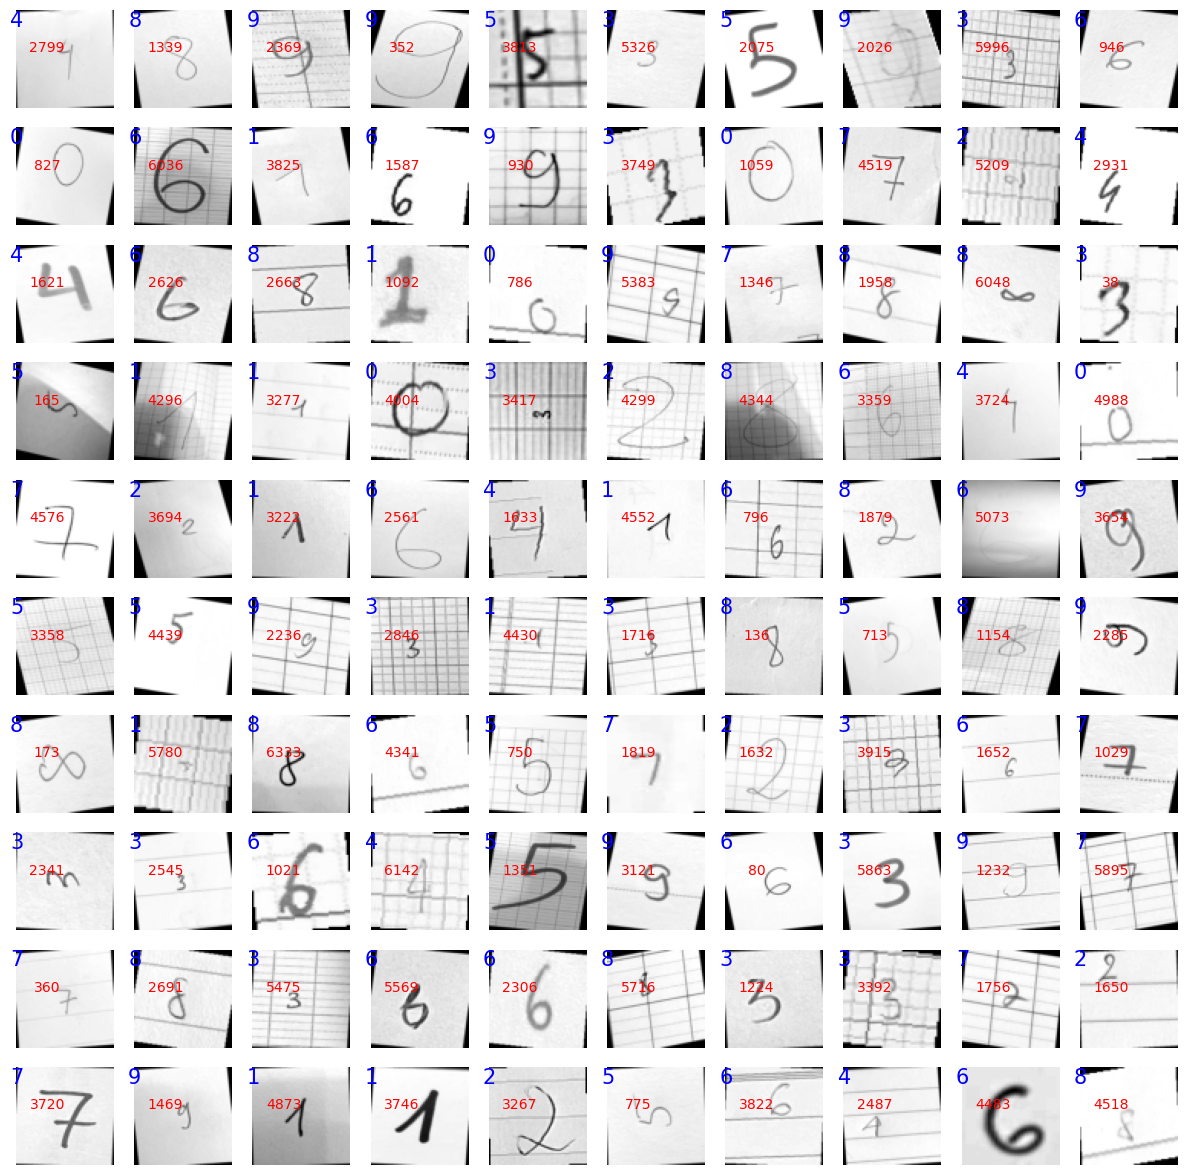

In [26]:
figure = plt.figure(figsize=(15, 15))
cols, rows = 10, 10
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.text(0, 0, str(label),
            ha="center", va="top", fontsize=15, color="blue")
    plt.text(20, 20, str(sample_idx),
            ha="center", va="top", fontsize=10, color="red")
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

# Model

In [27]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(image_size*image_size, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

# Use GPU to compute

In [28]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

model = NeuralNetwork().to(device)

print(model)
print(next(model.parameters()).device)


Using cuda device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=4096, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Linear(in_features=256, out_features=128, bias=True)
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Linear(in_features=128, out_features=10, bias=True)
  )
)
cuda:0


# Training

In [ ]:
learning_rate = 1e-4
batch_size = 64

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    total_loss, correct = 0, 0
    num_batches = len(dataloader)

    for batch, (X, y) in enumerate(dataloader):
        # Chuyển tensor sang gpu
        X = X.to(device)
        y = y.to(device)

        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

        if batch % 20 == 0:
            current = batch * batch_size + len(X)
            print(f"loss: {loss.item():>7f}  [{current:>5d}/{size:>5d}]")
        
        del X, y, pred, loss
        torch.cuda.empty_cache()

    avg_loss = total_loss / num_batches
    accuracy = correct / size
    print(f"Train Accuracy: {(100*accuracy):>0.1f}%, Avg loss: {avg_loss:>8f}")


best_correct = 0.0
def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            # Chuyển tensors sang gpu
            X = X.to(device)
            y = y.to(device)

            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

            del X, y, pred
            torch.cuda.empty_cache()

    test_loss /= num_batches
    correct /= size
    
    global best_correct
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    if test_loss < 2 and correct > best_correct:
            best_correct = correct
            torch.save(model.state_dict(), 'best_model.pth')
            print('SAVED!')

In [30]:
epochs = 50
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.304676  [   64/ 6406]
loss: 2.297220  [ 1344/ 6406]
loss: 2.339659  [ 2624/ 6406]
loss: 2.291074  [ 3904/ 6406]
loss: 2.281117  [ 5184/ 6406]
loss: 2.353061  [ 6406/ 6406]
Train Accuracy: 13.3%, Avg loss: 2.304713
Test Error: 
 Accuracy: 14.4%, Avg loss: 2.298664 

Epoch 2
-------------------------------
loss: 2.268878  [   64/ 6406]
loss: 2.215334  [ 1344/ 6406]
loss: 2.242175  [ 2624/ 6406]
loss: 2.289884  [ 3904/ 6406]
loss: 2.155471  [ 5184/ 6406]
loss: 2.285636  [ 6406/ 6406]
Train Accuracy: 18.3%, Avg loss: 2.221967
Test Error: 
 Accuracy: 21.2%, Avg loss: 2.177294 

Epoch 3
-------------------------------
loss: 2.152702  [   64/ 6406]
loss: 2.150005  [ 1344/ 6406]
loss: 2.088012  [ 2624/ 6406]
loss: 2.107420  [ 3904/ 6406]
loss: 2.072105  [ 5184/ 6406]
loss: 2.459346  [ 6406/ 6406]
Train Accuracy: 22.8%, Avg loss: 2.143039
Test Error: 
 Accuracy: 21.5%, Avg loss: 2.193383 

Epoch 4
-------------------------------
loss: 2.096556  [ 